In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
listings = pd.read_csv("data/listings.csv")
calendar = pd.read_csv("data/calendar.csv")
listings["availability_365"].head()

0    206
1     79
2    106
3     60
4    245
Name: availability_365, dtype: int64

In [3]:
calendar.head()   

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2371981,2025-09-30,f,NaN,NaN,2,20
1,2371981,2025-10-01,f,NaN,NaN,2,20
2,2371981,2025-10-02,f,NaN,NaN,2,20
3,2371981,2025-10-03,f,NaN,NaN,2,20
4,2371981,2025-10-04,f,NaN,NaN,2,20


In [4]:
listings['price'] = listings['price'].str.replace('$', '').str.replace(',','').astype(float)
print(listings['price'])

0         93.0
1        120.0
2         89.0
3          NaN
4        146.0
         ...  
8210     320.0
8211     203.0
8212     111.0
8213    9000.0
8214      91.0
Name: price, Length: 8215, dtype: float64


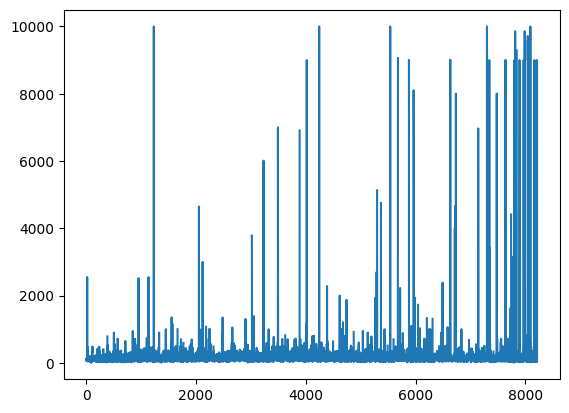

In [5]:
plt.plot(listings['price'])

In [6]:
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['weekday'] = calendar['date'].dt.weekday
calendar['booked'] = (calendar['available'] == 'f').astype(int)
calendar['month']= calendar['date'].dt.month

In [7]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights,weekday,booked,month
0,2371981,2025-09-30,f,NaN,NaN,2,20,1,1,9
1,2371981,2025-10-01,f,NaN,NaN,2,20,2,1,10
2,2371981,2025-10-02,f,NaN,NaN,2,20,3,1,10
3,2371981,2025-10-03,f,NaN,NaN,2,20,4,1,10
4,2371981,2025-10-04,f,NaN,NaN,2,20,5,1,10


In [18]:
#calculate booked days
ids = calendar['listing_id'].unique()

booked_days = calendar.groupby('listing_id')['booked'].sum()
booked_weekdays = calendar[calendar['weekday'] <= 4].groupby('listing_id')['booked'].sum()
booked_weekenddays = calendar[calendar['weekday'] > 4].groupby('listing_id')['booked'].sum()

booked_winter = calendar[calendar['month'].isin([12, 1, 2])].groupby('listing_id')['booked'].sum()
booked_spring = calendar[calendar['month'].isin([3, 4, 5])].groupby('listing_id')['booked'].sum()
booked_summer = calendar[calendar['month'].isin([6, 7, 8])].groupby('listing_id')['booked'].sum()
booked_fall = calendar[calendar['month'].isin([9, 10, 11])].groupby('listing_id')['booked'].sum()




In [19]:
calendar_features = pd.DataFrame({
    'listing_id': ids,
    'booked_days': booked_days,
    'booked_weekdays': booked_weekdays,
    'booked_weekenddays': booked_weekenddays,
    'booked_winter': booked_winter,
    'booked_spring': booked_spring,
    'booked_summer': booked_summer,
    'booked_fall':booked_fall
})

In [20]:
calendar_features = calendar_features.reset_index(drop=True)
df = calendar_features.merge(
    listings[['id', 'price', 'availability_365']],
    left_on='listing_id',
    right_on='id',
    how='left'
)

In [21]:
df["booked_range"] = df["booked_days"] / df["availability_365"].replace(0, np.nan)
df["booked_range"] = df["booked_range"].fillna(0)
df["booked_range"] = df["booked_range"].clip(0, 1)

print(df.head())

   listing_id  booked_days  booked_weekdays  booked_weekenddays  \
0     2371981          159              104                  55   
1     2377375          286              206                  80   
2     2388579          259              185                  74   
3     2425797          305              219                  86   
4     2450066          120               78                  42   

   booked_winter  booked_spring  booked_summer  booked_fall       id  price  \
0             31             48             37           43  2371981   30.0   
1             48             92             92           54  2377375  105.0   
2             20             77             92           70  2388579   74.0   
3             62             92             92           59  2425797  146.0   
4             27             54              0           39  2450066  183.0   

   availability_365  booked_range  
0                66      1.000000  
1               316      0.905063  
2             

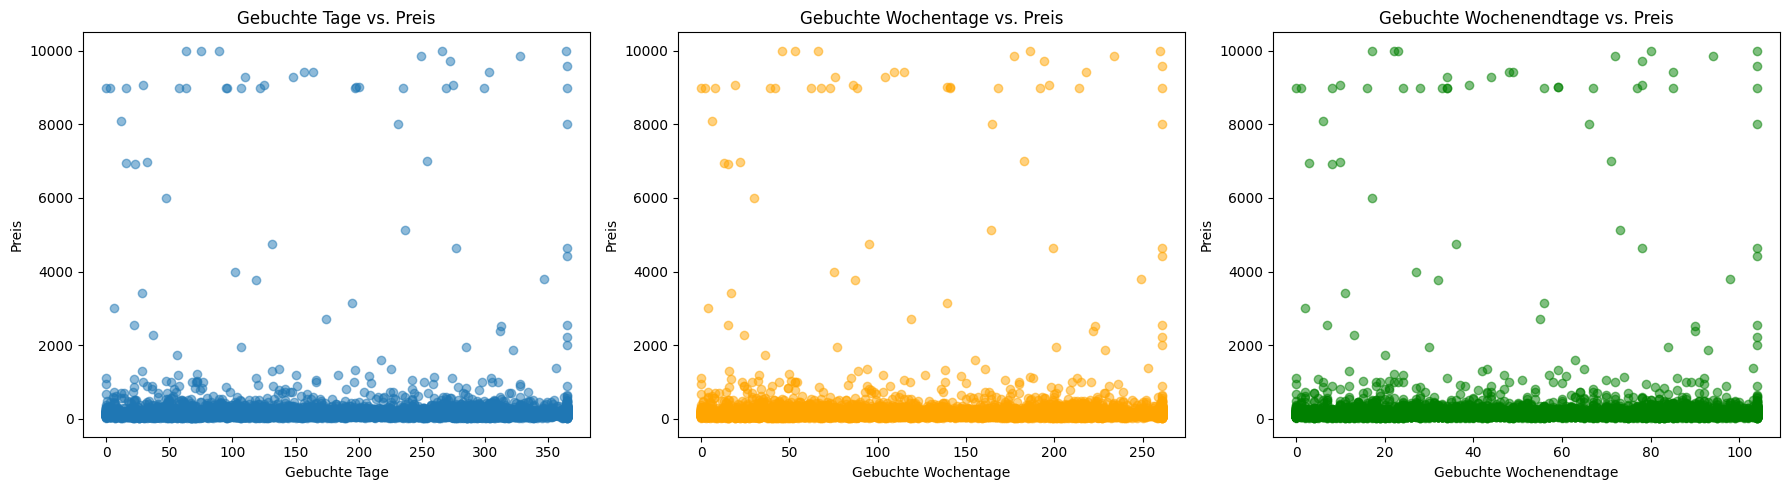

In [24]:
# plot booked days and price

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(df['booked_days'], df['price'], alpha=0.5)
plt.xlabel('Gebuchte Tage')
plt.ylabel('Preis')
plt.title('Gebuchte Tage vs. Preis')


plt.subplot(1, 3, 2)
plt.scatter(df['booked_weekdays'], df['price'], alpha=0.5, color='orange')
plt.xlabel('Gebuchte Wochentage')
plt.ylabel('Preis')
plt.title('Gebuchte Wochentage vs. Preis')

plt.subplot(1, 3, 3)
plt.scatter(df['booked_weekenddays'], df['price'], alpha=0.5, color='green')
plt.xlabel('Gebuchte Wochenendtage')
plt.ylabel('Preis')
plt.title('Gebuchte Wochenendtage vs. Preis')

plt.tight_layout()
plt.show()


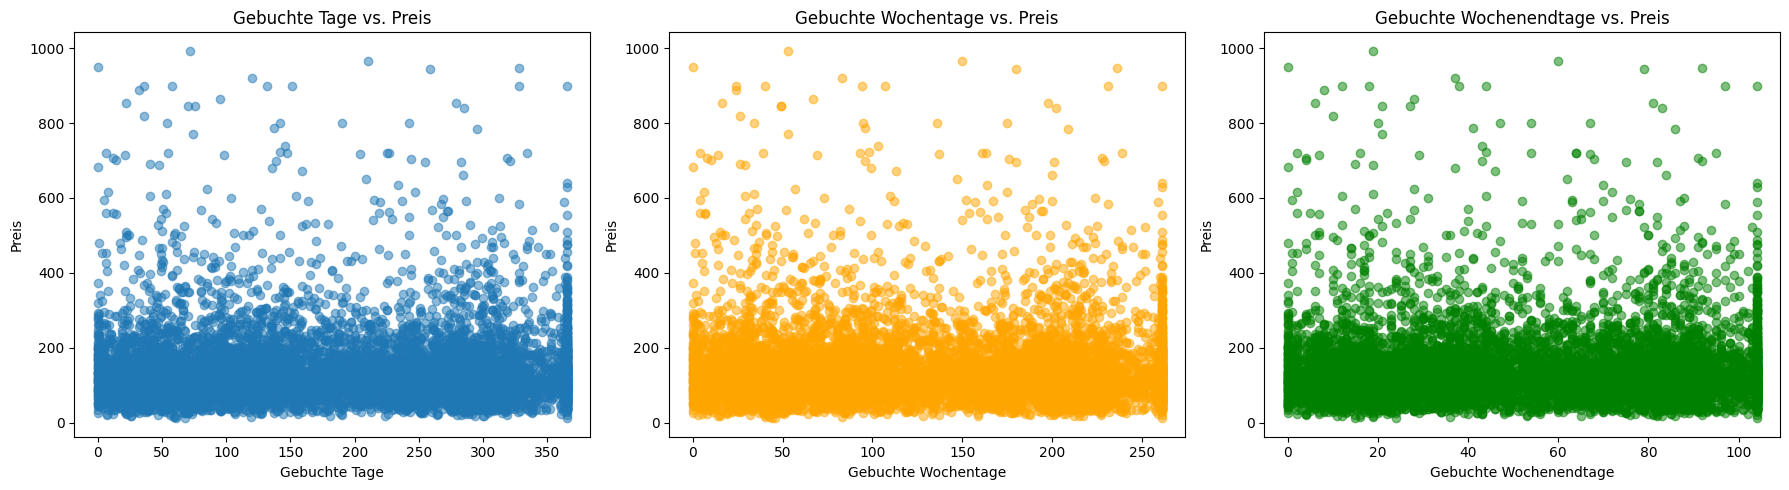

In [25]:
#for prices lower than 1000
df_filtered = df[df['price'] < 1000]

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(df_filtered['booked_days'], df_filtered['price'], alpha=0.5)
plt.xlabel('Gebuchte Tage')
plt.ylabel('Preis')
plt.title('Gebuchte Tage vs. Preis')

plt.subplot(1, 3, 2)
plt.scatter(df_filtered['booked_weekdays'], df_filtered['price'], alpha=0.5, color='orange')
plt.xlabel('Gebuchte Wochentage')
plt.ylabel('Preis')
plt.title('Gebuchte Wochentage vs. Preis')

plt.subplot(1, 3, 3)
plt.scatter(df_filtered['booked_weekenddays'], df_filtered['price'], alpha=0.5, color='green')
plt.xlabel('Gebuchte Wochenendtage')
plt.ylabel('Preis')
plt.title('Gebuchte Wochenendtage vs. Preis')

plt.tight_layout()
plt.show()

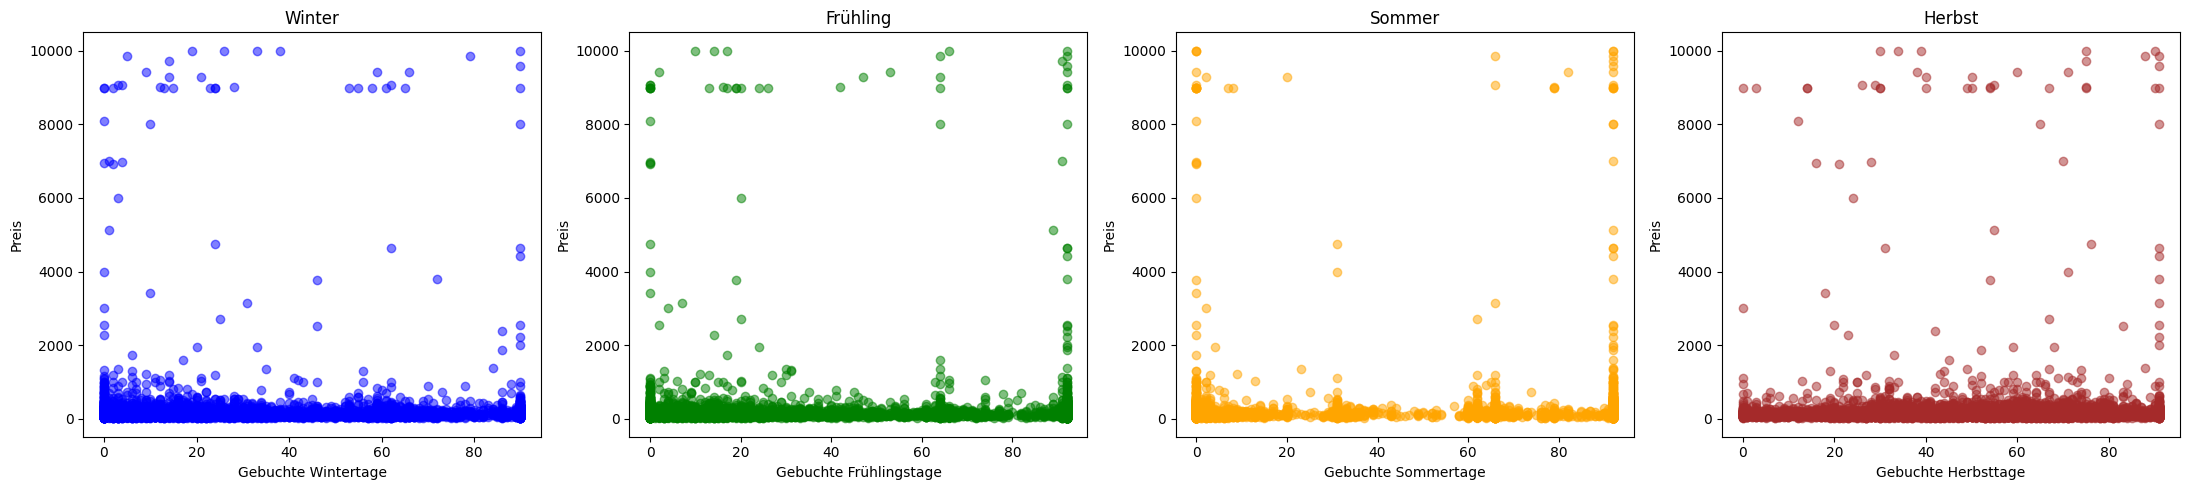

In [26]:
# same plot for seasons
plt.figure(figsize=(22, 5))

plt.subplot(1, 4, 1)
plt.scatter(df['booked_winter'], df['price'], alpha=0.5, color='blue')
plt.xlabel('Gebuchte Wintertage')
plt.ylabel('Preis')
plt.title('Winter')

plt.subplot(1, 4, 2)
plt.scatter(df['booked_spring'], df['price'], alpha=0.5, color='green')
plt.xlabel('Gebuchte Frühlingstage')
plt.ylabel('Preis')
plt.title('Frühling')

plt.subplot(1, 4, 3)
plt.scatter(df['booked_summer'], df['price'], alpha=0.5, color='orange')
plt.xlabel('Gebuchte Sommertage')
plt.ylabel('Preis')
plt.title('Sommer')

plt.subplot(1, 4, 4)
plt.scatter(df['booked_fall'], df['price'], alpha=0.5, color='brown')
plt.xlabel('Gebuchte Herbsttage')
plt.ylabel('Preis')
plt.title('Herbst')

plt.tight_layout()
plt.show()

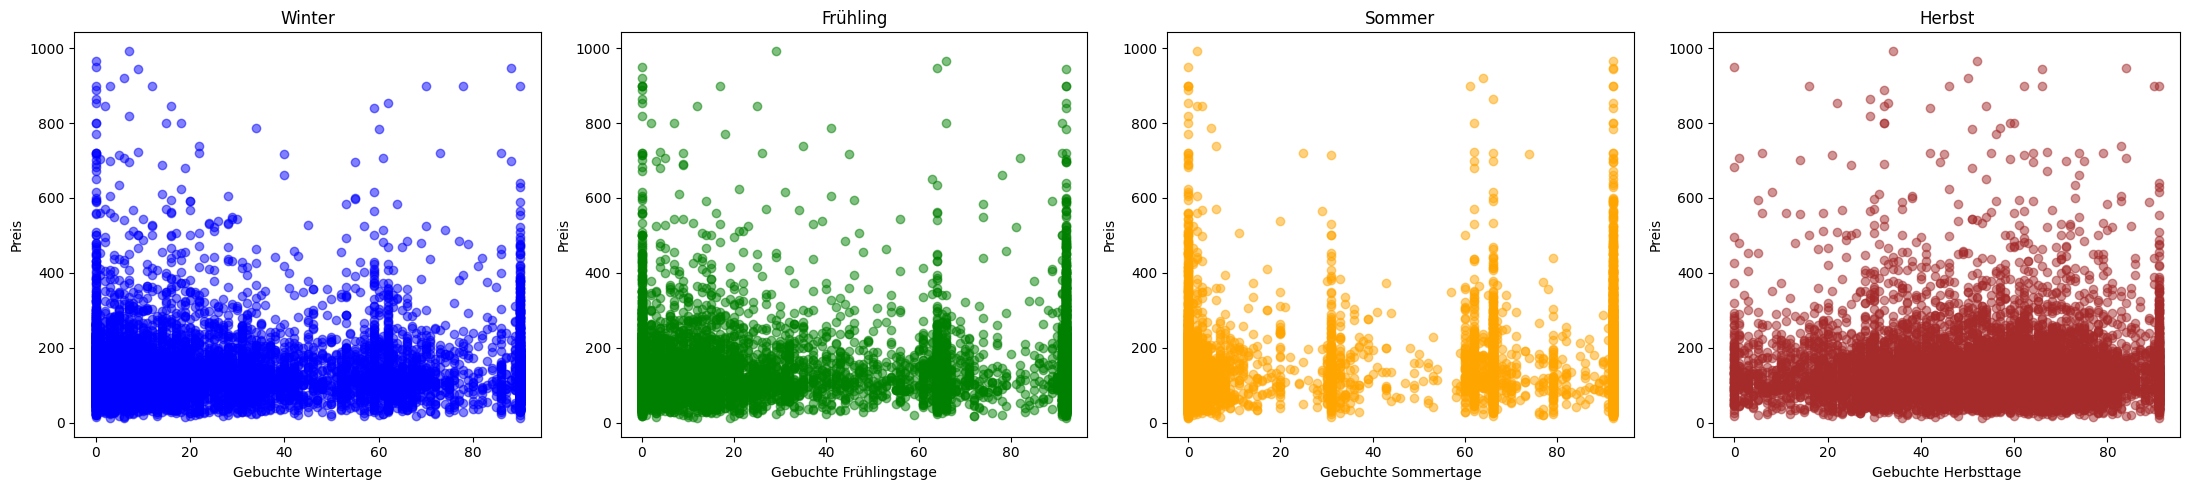

In [27]:
#again for prices lower than 1000
df_filtered = df[df['price'] < 1000]

plt.figure(figsize=(22, 5))

plt.subplot(1, 4, 1)
plt.scatter(df_filtered['booked_winter'], df_filtered['price'], alpha=0.5, color='blue')
plt.xlabel('Gebuchte Wintertage')
plt.ylabel('Preis')
plt.title('Winter')

plt.subplot(1, 4, 2)
plt.scatter(df_filtered['booked_spring'], df_filtered['price'], alpha=0.5, color='green')
plt.xlabel('Gebuchte Frühlingstage')
plt.ylabel('Preis')
plt.title('Frühling')

plt.subplot(1, 4, 3)
plt.scatter(df_filtered['booked_summer'], df_filtered['price'], alpha=0.5, color='orange')
plt.xlabel('Gebuchte Sommertage')
plt.ylabel('Preis')
plt.title('Sommer')

plt.subplot(1, 4, 4)
plt.scatter(df_filtered['booked_fall'], df_filtered['price'], alpha=0.5, color='brown')
plt.xlabel('Gebuchte Herbsttage')
plt.ylabel('Preis')
plt.title('Herbst')

plt.tight_layout()
plt.show()


In [28]:
#save results
df.to_csv("data/calender_features.csv", index=False)

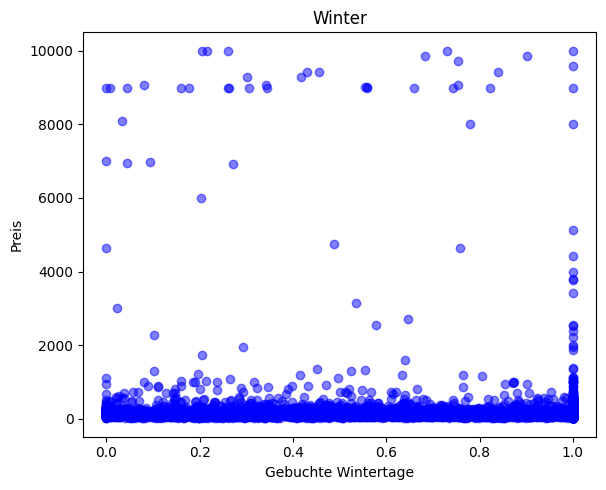

In [29]:
df_filtered = df[(df['price'] < 100000) & (df['booked_range']<=1)]

plt.figure(figsize=(22, 5))

plt.subplot(1, 4, 1)
plt.scatter(df_filtered['booked_range'], df_filtered['price'], alpha=0.5, color='blue')
plt.xlabel('Gebuchte Wintertage')
plt.ylabel('Preis')
plt.title('Winter')


plt.tight_layout()
plt.show()
